# Education and income: An empirical analysis


##Introduction

Education is commonly associated with higher earning potential, as it reflects accumulated skills, qualifications, and access to better job opportunities. Understanding how income levels vary with educational attainment is relevant for workforce analytics, compensation benchmarking, and policy discussions around human capital development. From a data analysis perspective, examining this relationship also provides an opportunity to explore how demographic and work-related factors interact with income outcomes.

This project analyzes the relationship between education and income using the Adult Census Income dataset, a widely used micro-level dataset derived from U.S. census records and accessed via Kaggle. The dataset contains individual demographic and employment characteristics such as age, gender, education level, working hours, occupation, and income category. The analysis focuses on preparing and cleaning the data, exploring income patterns across education levels, and estimating regression models to quantify how educational attainment is associated with income outcomes after controlling for relevant factors.

Income in this dataset is recorded as a binary category (earning more than or less than a specified threshold), rather than exact wage values. As a result, the analysis examines income likelihood and differentials rather than precise wage levels. Since the data is observational, the results are interpreted as associations rather than definitive causal effects. Potential limitations such as omitted variables and selection bias are discussed to ensure a transparent and responsible interpretation of the findings.

##Research questions

1) How does educational attainment relate to income levels in the Adult Census dataset?
2) Do individuals with more years of education have a higher probability of earning above the income threshold?
3) How do demographic and work-related factors interact with education in explaining income differences?

##Data description

The Adult Census Income dataset contains individual-level demographic and employment information for approximately 48842 observations. Key variables used in this analysis include years of education, age, hours worked per week, gender, and income category. Income is recorded as a binary variable indicating whether an individual earns above or below a specified threshold.

In [1]:
import pandas as pd
df = pd.read_csv('adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [2]:
df.shape

(48842, 15)

In [3]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
df.describe(include='all')

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,48842,4.884200e+04,48842,48842.000000,48842,48842,48842,48842,48842,48842.000000,48842.000000,48842.000000,48842,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,37155
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


## Data cleaning and variable preparation

In [6]:
(df == '?').sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [7]:
import numpy as np
df = df.replace('?',np.nan)

In [8]:
df.isnull().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [9]:
df = df.dropna()

In [10]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [11]:
cols = ['age','education','educational-num','hours-per-week','gender','income']
df_clean = df[cols].copy()

In [12]:
df_clean = df_clean.rename(columns={'educational-num':'years_education','hours-per-week':'hours_per_week'})

In [13]:
df_clean['high_income']= df_clean['income'].apply(lambda x: 1 if x == '>50K' else 0)

In [14]:
df_clean.head()

,age,education,years_education,hours_per_week,gender,income,high_income
0,25,11th,7,40,Male,<=50K,0
1,38,HS-grad,9,50,Male,<=50K,0
2,28,Assoc-acdm,12,40,Male,>50K,1
3,44,Some-college,10,40,Male,>50K,1
5,34,10th,6,30,Male,<=50K,0


In [15]:
df_clean['high_income'].value_counts(normalize='True')

,proportion
high_income,
0,0.752156
1,0.247844


After handling missing values and selecting relevant variables, a cleaned dataset was constructed containing demographic characteristics, education level, work intensity, and income category. Income was converted into a binary variable indicating whether an individual earns above the specified threshold

## Exploratory data analysis

This section explores the distribution of income and examines how education and other demographic factors relate to income outcomes.

In [16]:
df_clean['high_income'].value_counts(normalize = 'True')

,proportion
high_income,
0,0.752156
1,0.247844


A majority of individuals in the dataset earn below the income threshold, indicating a moderately imbalanced income distribution.

## Education vs income

In [17]:
edu_income = df_clean.groupby("years_education")["high_income"].mean()
edu_income

,high_income
years_education,
1,0.013889
2,0.036036
3,0.048998
4,0.066829
5,0.056213
6,0.067048
7,0.054972
8,0.074523
9,0.163431


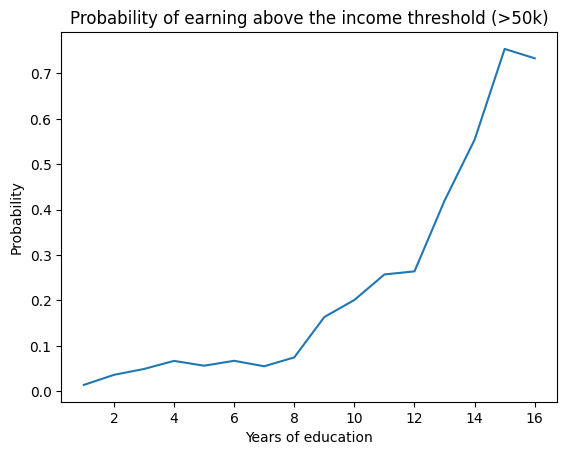

In [18]:
import matplotlib.pyplot as plt
edu_income.plot(kind='line')
plt.xlabel('Years of education')
plt.ylabel('Probability')
plt.title('Probability of earning above the income threshold (>50k)')
plt.show()

The probability of earning above the income threshold increases with years of education, suggesting a positive association between educational attainment and income outcomes.

## Education distribution

In [19]:
edu_dist = df_clean['years_education'].value_counts().sort_index()
edu_dist

,count
years_education,
1,72
2,222
3,449
4,823
5,676
6,1223
7,1619
8,577
9,14783


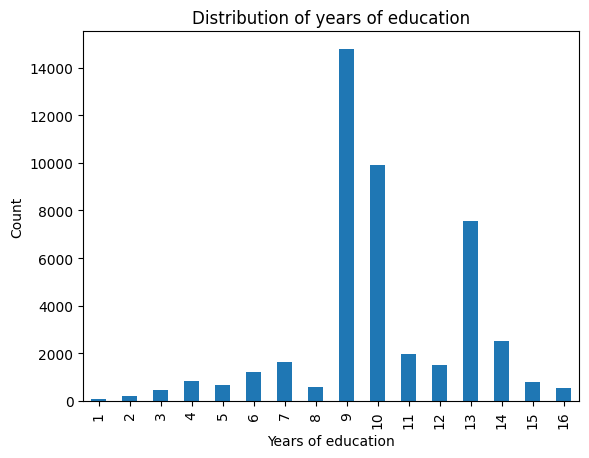

In [20]:
edu_dist.plot(kind='bar')
plt.xlabel('Years of education')
plt.ylabel('Count')
plt.title('Distribution of years of education')
plt.show()

## Work intensity

In [21]:
work_intensity = df_clean.groupby('high_income')['hours_per_week'].mean()
work_intensity

,hours_per_week
high_income,
0,39.372023
1,45.690489


<Figure size 640x480 with 0 Axes>

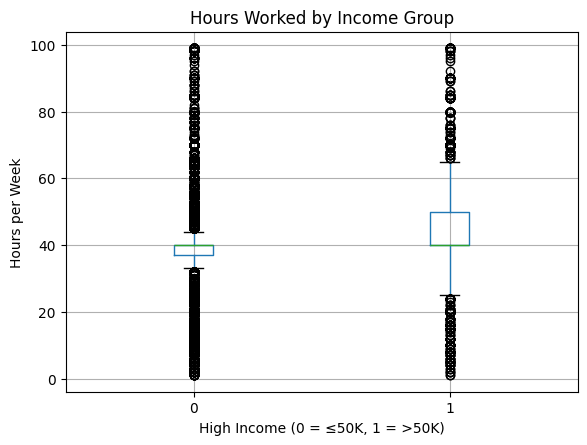

In [22]:
plt.figure()
df_clean.boxplot(column="hours_per_week", by="high_income")
plt.title("Hours Worked by Income Group")
plt.suptitle("")
plt.xlabel("High Income (0 = ≤50K, 1 = >50K)")
plt.ylabel("Hours per Week")
plt.show()

Individuals earning above the income threshold tend to work more hours per week on average, highlighting the role of work intensity in income outcomes.

## Gender & income

In [23]:
gender_income = df_clean.groupby('gender')['high_income'].mean()
gender_income

,high_income
gender,
Female,0.113576
Male,0.312477


Income probabilities differ across gender groups, indicating that demographic factors interact with education in shaping income outcomes.

## EDA Summary

Exploratory analysis indicates a strong positive association between years of education and the probability of earning above the income threshold. However, income outcomes are also influenced by work intensity and demographic factors such as gender. These patterns motivate the use of regression analysis to quantify the relationship between education and income while controlling for relevant variables.

## Regression analysis

We begin by estimating a simple model examining the relationship between years of education and the probability of earning above the income threshold.

In [24]:
import statsmodels.api as sm
x = df_clean["years_education"]
y = df_clean["high_income"]
x = sm.add_constant(x)
model1 = sm.OLS(y, x).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            high_income   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     5632.
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        07:10:15   Log-Likelihood:                -23532.
No. Observations:               45222   AIC:                         4.707e+04
Df Residuals:                   45220   BIC:                         4.709e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.3217      0.008    -

The regression results indicate a positive and statistically significant association between years of education and the probability of earning above the income threshold. Each additional year of education is associated with an 5.6 percentage points increase in the likelihood of high income.

## Adding controls

We next extend the model by controlling for demographic and work-related factors.

In [25]:
df_clean["female"] = (df_clean["gender"] == "Female").astype(int)
x2 = df_clean[["years_education", "age", "hours_per_week", "female"]]
x2 = sm.add_constant(x2)
y = df_clean["high_income"]
model2 = sm.OLS(y, x2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            high_income   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     3075.
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        07:10:15   Log-Likelihood:                -20746.
No. Observations:               45222   AIC:                         4.150e+04
Df Residuals:                   45217   BIC:                         4.155e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.6575      0.010    -

After controlling for age, hours worked per week, and gender, years of education remains positively and statistically significantly associated with the probability of earning above the income threshold. Specifically, each additional year of education is associated with approximately a 5.2 percentage point increase in the probability of earning above the threshold, holding other factors constant.

Age and work intensity are also positively associated with high-income status. Older individuals and those who work more hours per week exhibit a higher likelihood of earning above the income threshold, reflecting the importance of labor market experience and work intensity in income outcomes.

The coefficient on the gender indicator suggests that, conditional on education, age, and hours worked, female individuals are associated with a lower probability of earning above the income threshold compared to males. This highlights the presence of gender-related income disparities that persist even after accounting for key observable characteristics.

## Model comparison

Comparing the baseline and controlled specifications highlights the importance of accounting for demographic and labor supply factors. The estimated return to education declines slightly after adding controls (from approximately 5.6 to 5.2 percentage points), indicating that part of the raw education–income association reflects correlated characteristics such as age and work intensity. However, the education coefficient remains large and statistically significant, suggesting that education retains an independent association with income outcomes

## Limitations

Comparing the baseline and controlled specifications highlights the importance of accounting for demographic and labor supply factors. The estimated return to education declines slightly after adding controls (from approximately 5.6 to 5.2 percentage points), indicating that part of the raw education–income association reflects correlated characteristics such as age and work intensity. However, the education coefficient remains large and statistically significant, suggesting that education retains an independent association with income outcomes

## Robustness check: Logistic regression.

As a robustness check, a logistic regression model is estimated to verify whether the qualitative relationship between education and income remains consistent.

In [26]:
logit_model = sm.Logit(y, x2).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.437215
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            high_income   No. Observations:                45222
Model:                          Logit   Df Residuals:                    45217
Method:                           MLE   Df Model:                            4
Date:                Wed, 25 Feb 2026   Pseudo R-squ.:                  0.2192
Time:                        07:10:16   Log-Likelihood:                -19772.
converged:                       True   LL-Null:                       -25322.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -7.9121      0.095    -83.701      0.000      -8.097      -7.727
years_educatio

As a robustness check, a logistic regression model was estimated. The results are consistent with the linear probability model, showing that years of education is positively and statistically significantly associated with the likelihood of earning above the income threshold. Age and hours worked per week are also positively associated with high-income status, while the gender coefficient indicates that females have a lower likelihood of earning above the threshold, holding other factors constant. Overall, the logistic regression confirms the qualitative findings from the baseline analysis.